In [1]:
import matplotlib.pyplot as plt 
import numpy as np 
import os 
import pandas as pd # 

In [2]:
df = pd.read_csv('match_data_300_tourns_modified.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34521 entries, 0 to 34520
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player1                   34521 non-null  object 
 1   player2                   34521 non-null  object 
 2   best_of                   34521 non-null  int64  
 3   player1_elo               34521 non-null  int64  
 4   player2_elo               34521 non-null  int64  
 5   elo_match_win_rate        34521 non-null  float64
 6   elo_frame_win_rate        34521 non-null  float64
 7   p1_matches_played         34521 non-null  int64  
 8   p1_matches_won            34521 non-null  int64  
 9   p1_frames_played          34521 non-null  int64  
 10  p1_frames_won             34521 non-null  int64  
 11  p2_matches_played         34521 non-null  int64  
 12  p2_matches_won            34521 non-null  int64  
 13  p2_frames_played          34521 non-null  int64  
 14  p2_fra

In [4]:
from sklearn.metrics import mean_absolute_error

# Calculate MSE
y_true = df['win_percentage']
y_pred = df['elo_frame_win_rate']
elo_mse = mean_absolute_error(y_true, y_pred)

print("Elo Root Mean Squared Error:", elo_mse)

Elo Root Mean Squared Error: 0.21939344778504524


In [5]:
y_true = df['win_percentage']
y_pred = df['elo_frame_win_rate']

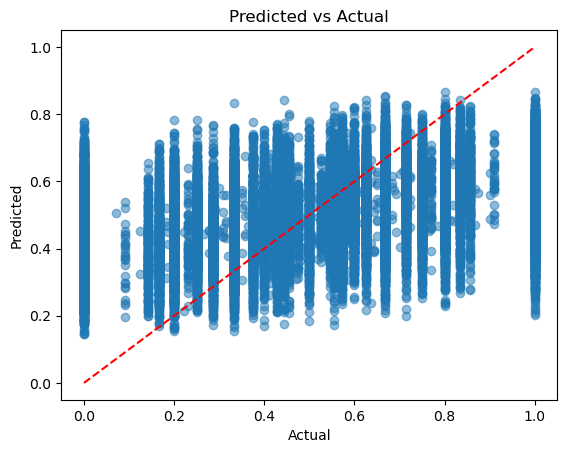

In [6]:
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.show()


Elo win predictions typically range from around 0.18 to 0.8. However, in reality, there are matches where a player completely dominates and wins all the frames. Since Elo ratings always assign each player a nonzero chance of winning and all players have non-zero rating points, the predicted probabilities are never exactly 0 or 1. While this approach is generally suitable for sports predictions, it doesn't account for extreme outcomes, leading to some large prediction errors.

In [7]:
residuals = y_true-y_pred

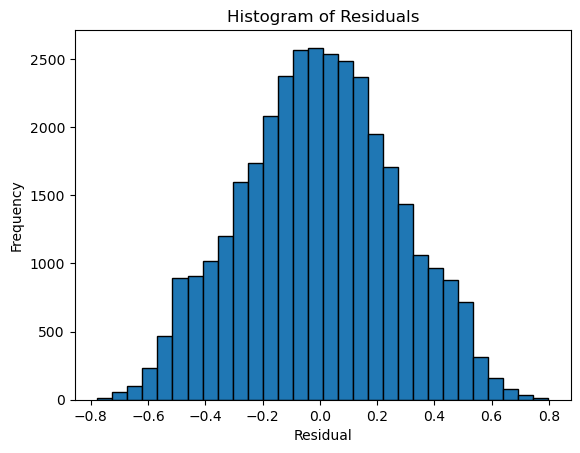

In [8]:
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()


#### Train test split

We divide our data into train and test split by keeping the last 20% of the data for testing our models at the end. The remaining 80% is used for traing and cross validation while training for hyperparameter tuning. We use mean absolute error (MAE) as the performance metic for the models.

As a first step, we apply the performance metric to evaluate the Elo-based predictions.

In [9]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, 
                                        test_size = 0.2,
                                        shuffle=False)


##### MAE on final test set
This step will be done for the other models only at the very end once we have done hyperparameter tuning with the rest of the data.

In [10]:
from sklearn.metrics import mean_absolute_error
y_test = df_test["win_percentage"]
y_pred = df_test["elo_frame_win_rate"]

rmse = mean_absolute_error(y_test, y_pred)
print(f"MAE for elo on test set:   {rmse:.4f}")

MAE for elo on test set:   0.2210
